# From hazard curves to portfolio VaR / CVaR

Event-aligned RP tables answer "how deep / how damaged at the 100-year event?"
**crc-framework** answers a different question: given each asset's full exposure
and impact distributions, what is the portfolio's value-at-risk across jointly
realized downside branches?

1. **Match** assets to canonical hazard rows (exact source geometry).
2. **Microscores** — `generate_microscores(exposure, impact=...)` per asset.
3. **Aggregate** — `compute_risk` over dollar `BinaryOutcome`s → VaR, CVaR, attribution.

This notebook is the bridge from crc-sdk's hazard surface to crc-framework's
risk metrics.


**Workflow:** [AI skill](../.agents/skills/crc-assess-asset-portfolio-risk/SKILL.md) · [Python pipeline](../pipelines/portfolio_risk_pipeline.py) · [Setup and tested versions](../ai-playbooks/docs/setup.md) · [All problems](../README.md#choose-a-problem)

### Viewing this notebook

**GitHub:** saved tables and PNG figures below show the completed run; no execution
is needed. **JupyterLab / compatible editors:** run all cells for interactive
Plotly charts with hover, zoom and pan. Each figure also includes a static PNG
fallback. Maps need internet access for basemap tiles; PMTiles downloads, where
provided, open separately in a compatible viewer.


In [1]:
from dataclasses import replace
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow.parquet as pq

from crc_framework import (
    PiecewiseLinearImpact,
    ScenarioMetadata,
    compute_risk,
    generate_microscores,
)
from crc_sdk.connectors import read_hazard_metadata
from crc_sdk.connectors.duckdb import DuckDBConnection, sql_quote
from crc_sdk.workflows import distribution_from_hazard_row

# One MIME bundle: interactive Plotly where supported, PNG for GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 1100
pio.renderers["png"].height = 550
pio.renderers["png"].scale = 1

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
FIXTURE_DIR = Path("../fixtures/os_climate")

HAZARD_NAME = "RiverineInundation"
PATHWAY = "historical"
HORIZON = 1980
DESIGN_PROBABILITY = 0.99
MICROSCORE_PROBABILITIES = (0.5, 0.8, 0.9, 0.95, 0.99, 0.999)
RISK_LEVELS = (0.5, 0.95, 0.99)

HAZARD_PATH = FIXTURE_DIR / "hazard.parquet"
ASSETS_PATH = FIXTURE_DIR / "assets.parquet"
H3_RESOLUTION = read_hazard_metadata(HAZARD_PATH).h3_resolution

DEPTH_DAMAGE = PiecewiseLinearImpact(
    exposure=[0.0, 0.1, 0.5, 1.0, 2.0, 4.0],
    impact=[0.0, 0.01, 0.08, 0.22, 0.55, 1.0],
)


## 1. Local fixtures and exact geometry match

Load the checked-in Cologne assets and canonical hazard, then reproduce the
portfolio evaluator's H3 + exact source-geometry match in DuckDB.


In [2]:
assets = pq.read_table(ASSETS_PATH)
con = DuckDBConnection.for_analytics(
    DATA_DIR, extensions=("spatial", "h3")
).connect()
matched = con.execute(
    f"""
    SELECT a.asset_id, a.sector, a.replacement_value,
           a.longitude, a.latitude, h.*
    FROM read_parquet({sql_quote(str(ASSETS_PATH))}) a
    JOIN read_parquet({sql_quote(str(HAZARD_PATH))}) h
      ON h3_latlng_to_cell(a.latitude, a.longitude, {H3_RESOLUTION}) = h.cell_index
     AND (h.source_geometry IS NULL
          OR ST_Covers(
                 ST_GeomFromWKB(h.source_geometry),
                 ST_Point(a.longitude, a.latitude)
             ))
    WHERE h.hazard_name = {sql_quote(HAZARD_NAME)}
      AND h.horizon = {HORIZON}
      AND h.pathway = {sql_quote(PATHWAY)}
    """
).arrow().read_all().to_pandas()
assert len(matched) == assets.num_rows
matched[["asset_id", "sector", "replacement_value", "cell_index", "curve_kind"]]


,asset_id,sector,replacement_value,cell_index,curve_kind
0,warehouse-a,logistics,12000000,617549611779227647,hurdle
1,warehouse-b,logistics,8500000,617549611779227647,hurdle
2,warehouse-c,manufacturing,21000000,617549611779227647,hurdle


## 2. Microscores per asset

`distribution_from_hazard_row` rebuilds the hurdle; `generate_microscores` samples
exposure and the impact transform onto a shared probability grid. `.at(0.99)`
returns a `BinaryOutcome` for the 100-year threshold — downside probability and
impact ratio — which we scale by replacement value to dollars.


In [3]:
outcomes = []
micro_rows = []
for row in matched.to_dict(orient="records"):
    exposure = distribution_from_hazard_row(row)
    suite = generate_microscores(
        exposure,
        impact=DEPTH_DAMAGE,
        probabilities=MICROSCORE_PROBABILITIES,
        metadata=ScenarioMetadata(
            factor=row["asset_id"],
            pathway=PATHWAY,
            horizon=HORIZON,
        ),
    )
    binary = suite.at(DESIGN_PROBABILITY)
    dollar = replace(
        binary,
        factor=row["asset_id"],
        weight=1.0,
        downside_impact=float(binary.downside_impact)
        * float(row["replacement_value"]),
    )
    outcomes.append(dollar)
    stats = suite.impact_statistics
    micro_rows.append(
        {
            "asset_id": row["asset_id"],
            "downside_probability": binary.downside_probability,
            "damage_ratio": binary.downside_impact,
            "downside_usd": dollar.downside_impact,
            "impact_mean": None if stats is None else stats.mean,
            "impact_cvar_95": None if stats is None else stats.cvar_95,
        }
    )
micro = pd.DataFrame(micro_rows)
micro


,asset_id,downside_probability,damage_ratio,downside_usd,impact_mean,impact_cvar_95
0,warehouse-a,0.01,0.451665,5.419986e+06,0.042104,0.348237
1,warehouse-b,0.01,0.451665,3.839156e+06,0.042104,0.348237
2,warehouse-c,0.01,0.451665,9.484975e+06,0.042104,0.348237


## 3. Portfolio VaR / CVaR with attribution

`compute_risk` expands the binary outcomes into a spanning set of joint
realizations and reports VaR / CVaR at requested probability levels, plus
per-factor attribution of those measures.

This example uses independent binary outcomes at one selected probability
threshold, not a calibrated joint continuous-loss model. Branch count grows as
`2**n`; apply a branch limit and justify dependence assumptions before scaling.


In [4]:
risk = compute_risk(outcomes, levels=RISK_LEVELS)
print(f"spanning branches: {risk.branch_count}")

level_rows = []
attr_rows = []
for level in risk.levels:
    level_rows.append(
        {"probability": level.probability, "var": level.var, "cvar": level.cvar}
    )
    for item in level.attribution:
        attr_rows.append(
            {
                "probability": level.probability,
                "factor": item.factor,
                "var_impact": item.var_impact,
                "cvar_impact": item.cvar_impact,
            }
        )
levels = pd.DataFrame(level_rows)
attribution = pd.DataFrame(attr_rows)
levels


spanning branches: 8


,probability,var,cvar
0,0.50,0.000000e+00,1.249608e+05
1,0.95,0.000000e+00,1.249608e+06
2,0.99,3.086381e+06,3.192522e+06


## 4. Visualize


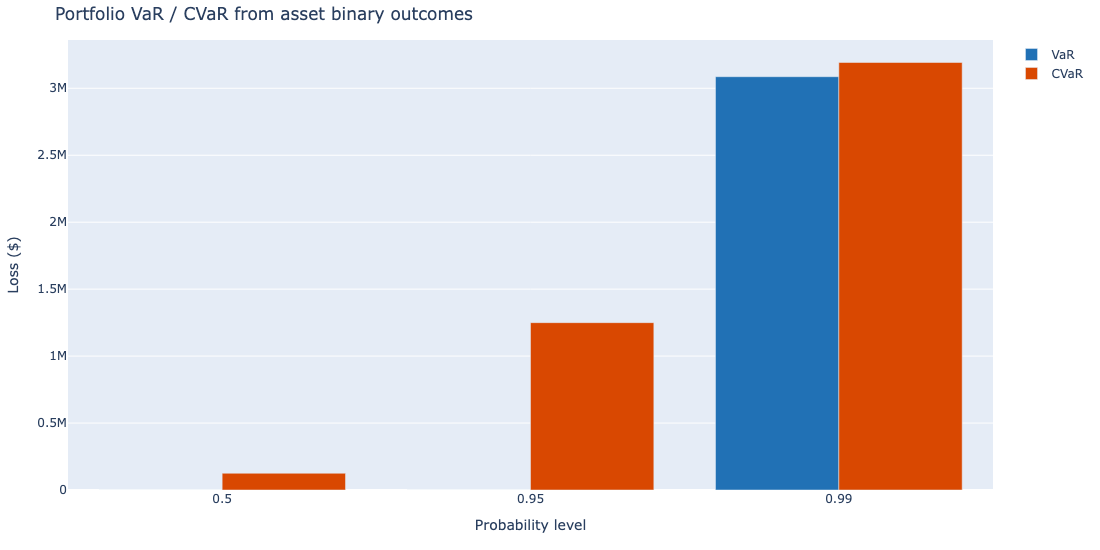

In [5]:
fig_risk = go.Figure()
fig_risk.add_trace(
    go.Bar(
        name="VaR",
        x=[str(p) for p in levels["probability"]],
        y=levels["var"],
        marker_color="#2171B5",
    )
)
fig_risk.add_trace(
    go.Bar(
        name="CVaR",
        x=[str(p) for p in levels["probability"]],
        y=levels["cvar"],
        marker_color="#D94801",
    )
)
fig_risk.update_layout(
    barmode="group",
    title="Portfolio VaR / CVaR from asset binary outcomes",
    xaxis_title="Probability level",
    yaxis_title="Loss ($)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_risk.show()


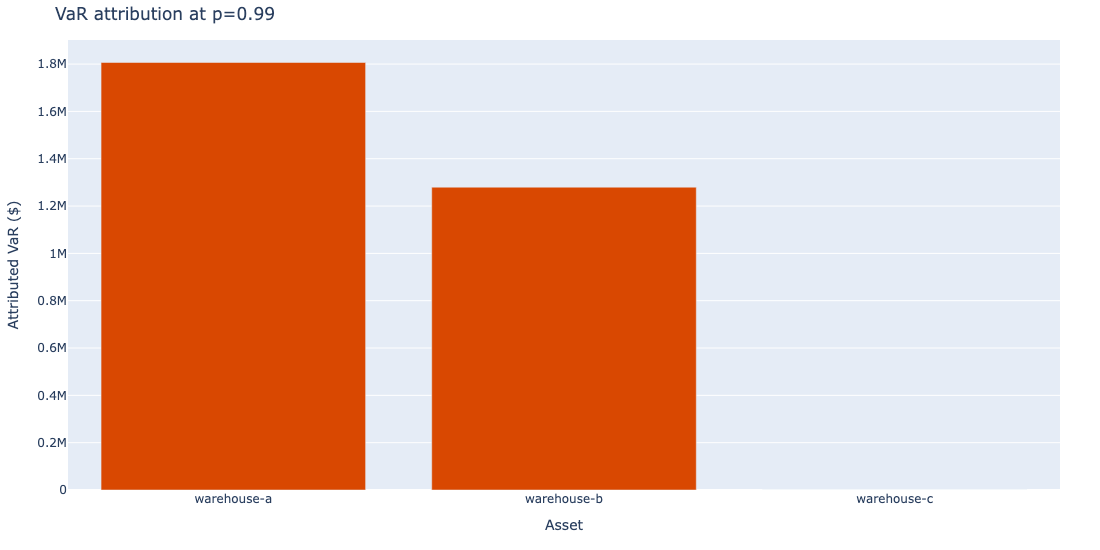

,probability,factor,var_impact,cvar_impact
0,0.50,warehouse-a,0.000000e+00,3.613324e+04
1,0.50,warehouse-b,0.000000e+00,2.559438e+04
2,0.50,warehouse-c,0.000000e+00,6.323317e+04
3,0.95,warehouse-a,0.000000e+00,3.613324e+05
4,0.95,warehouse-b,0.000000e+00,2.559438e+05
5,0.95,warehouse-c,0.000000e+00,6.323317e+05
6,0.99,warehouse-a,1.806662e+06,1.806662e+04
7,0.99,warehouse-b,1.279719e+06,1.279719e+04
8,0.99,warehouse-c,0.000000e+00,3.161658e+06


In [6]:
design_attr = attribution[attribution["probability"] == 0.99]
fig_attr = go.Figure(
    go.Bar(
        x=design_attr["factor"],
        y=design_attr["var_impact"],
        marker_color="#D94801",
        name="VaR attribution",
    )
)
fig_attr.update_layout(
    title="VaR attribution at p=0.99",
    xaxis_title="Asset",
    yaxis_title="Attributed VaR ($)",
    margin=dict(l=60, r=40, t=40, b=60),
)
fig_attr.show()
attribution


## Scaling this up

[`pipelines/portfolio_risk_pipeline.py`](../pipelines/portfolio_risk_pipeline.py)
is the headless twin — match → microscores → `compute_risk`, writing attribution
rows to Parquet. For larger books, the match stays a DuckDB join; microscore
generation is the per-asset Python/Rust step to parallelize externally.
